# Parameter quality evaluation

In this notebook we evaluate parameter quality on the quantum hardware.

In [2]:
import json
import glob
import matplotlib.pyplot as plt

from qaoa_parameter_setting.utils.hardware_execution import HarwareExecutor

CalledProcessError: Command '['/home/jjuradod/.julia/environments/pyjuliapkg/pyjuliapkg/install/bin/julia', '--project=/home/jjuradod/.julia/environments/pyjuliapkg', '--startup-file=no', '-O0', '--compile=min', '-e', 'import Libdl; print(abspath(Libdl.dlpath("libjulia")), "\\0", Sys.BINDIR)']' returned non-zero exit status 1.

The cell below can be used to get a sense of how much data there is for the different graphs. It is optional to run, it helps pick an instance to analyze.

In [ ]:
with open("data/training/best_parameters_summary.json", "r") as fin:
    summary = json.load(fin)

summary["MPS"].keys()

In [24]:
instance = "001_10nodes_random3regular.json"
short_name = "001N10R3R"
folder = "random_regular"

executor = HarwareExecutor(instance, short_name, folder)

TypeError: '>' not supported between instances of 'NoneType' and 'float'

In [4]:
print(executor._all_methods_summary.keys())

dict_keys(['FA_SV_noOpt', 'FA_SV_opt', 'TQA_SV_noOpt', 'I_SV', 'F_SV', 'TQA_SV_opt'])


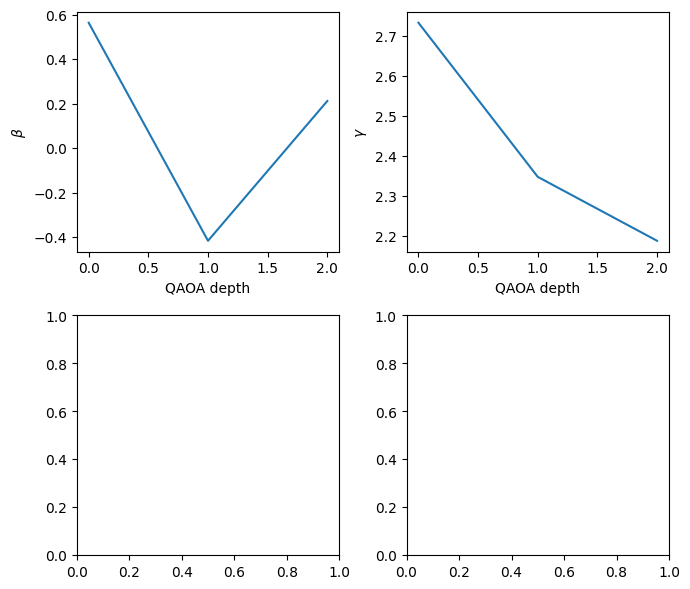

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(7, 6))
executor.plot_qaoa_angles(3, fig, axs[0][0], axs[0][1])
fig.tight_layout()

## Build the QAOA circuit

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

In [6]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="IwdZl1my9sNlILf88ZrZmb0vqCLqyoj6wlG_R7D1gF88",
    overwrite=True
)

In [7]:
service = QiskitRuntimeService(instance="PremAccess")
backend = service.backend("ibm_pittsburgh")

In [8]:
pub = executor.make_sampler_pub(backend, qaoa_depth=1, problem_class="maxcut")

In [11]:
print("Instruction count:", pub[0].count_ops())
print("2Q gate depth:", pub[0].depth(lambda x: len(x.qubits) > 1))

Instruction count: OrderedDict([('sx', 319), ('rz', 299), ('cz', 162), ('measure', 20)])
2Q gate depth: 19


In [10]:
pub[0].draw("mpl", fold=False, idle_wires=False)

### Execute on the hardware

In [14]:
sampler = SamplerV2(mode=backend)

In [15]:
job = sampler.run(pub, shots=2**12)

In [37]:
print(job.status())
print(job.job_id())

QUEUED
d4fp146lo8as739ovb5g


Get the result and save it. This is to be run when the job is done.

In [9]:
job_ = service.job("d4fp146lo8as739ovb5g")
print(job_)

<RuntimeJobV2('d4fp146lo8as739ovb5g', 'sampler')>


In [10]:
res_summary = executor.save_result_summary(job_)

### Load results from past executions and plot them

In [13]:
with open(f"data/hardware/{folder}/{short_name}_d4fp146lo8as739ovb5g.json", "r") as fin:
    res_summary = json.load(fin)

In [14]:
import numpy as np

from qaoa_training_pipeline.visualization.plotting import plot_cdf
from qaoa_training_pipeline.utils.graph_utils import load_graph, solve_max_cut, graph_to_operator

from qopt_best_practices.cost_function.cost_utils import counts_to_maxcut_cost

from qaoa_parameter_setting.utils.analysis import mean_obj, standard_error_mean

To compute performance we need to get the graph and the extremal values of the objective to compute the approximation ratio.

In [15]:
graph = load_graph(f"instances/{folder}/{instance}")
cost_op = graph_to_operator(graph, pre_factor=-0.5)

In [16]:
max_cut, min_cut, _ = solve_max_cut(cost_op)

We compare the cumulative distributions of the samples from the methods as well as the mean of these distributions.

In [17]:
mc_costs = [counts_to_maxcut_cost(graph, res["counts"]) for res in res_summary]
print(mc_costs)

[defaultdict(<class 'float'>, {15.0: 0.153076171875, 14.0: 0.143310546875, 10.0: 0.020751953125, 19.0: 0.052978515625, 17.0: 0.120361328125, 13.0: 0.110595703125, 20.0: 0.025390625, 11.0: 0.051513671875, 18.0: 0.078857421875, 16.0: 0.14599609375, 12.0: 0.072021484375, 9.0: 0.006103515625, 7.0: 0.0009765625, 21.0: 0.009033203125, 23.0: 0.00146484375, 22.0: 0.003173828125, 8.0: 0.003173828125, 24.0: 0.001220703125}), defaultdict(<class 'float'>, {21.0: 0.013916015625, 15.0: 0.154052734375, 16.0: 0.151611328125, 12.0: 0.071533203125, 18.0: 0.079833984375, 17.0: 0.11962890625, 19.0: 0.049560546875, 13.0: 0.108642578125, 10.0: 0.017578125, 20.0: 0.030517578125, 11.0: 0.050537109375, 14.0: 0.1376953125, 22.0: 0.00341796875, 9.0: 0.007568359375, 8.0: 0.001953125, 7.0: 0.00048828125, 23.0: 0.001220703125, 6.0: 0.000244140625}), defaultdict(<class 'float'>, {18.0: 0.08447265625, 20.0: 0.026611328125, 17.0: 0.117919921875, 10.0: 0.0205078125, 16.0: 0.1474609375, 15.0: 0.15087890625, 19.0: 0.0505

In [18]:
means = [100*(mean_obj(mc_cost) - min_cut)/(max_cut - min_cut) for mc_cost in mc_costs]
sems = np.array([100*(standard_error_mean(mc_cost, sum(res_summary[idx]["counts"].values())))/(max_cut - min_cut) for idx, mc_cost in enumerate(mc_costs)])
print(max_cut)
print(min_cut)
print(means)

26.0
0.0
[58.09326171875, 58.35993840144231, 58.15335787259615]


Text(0.5, 0, 'Best approximated energy')

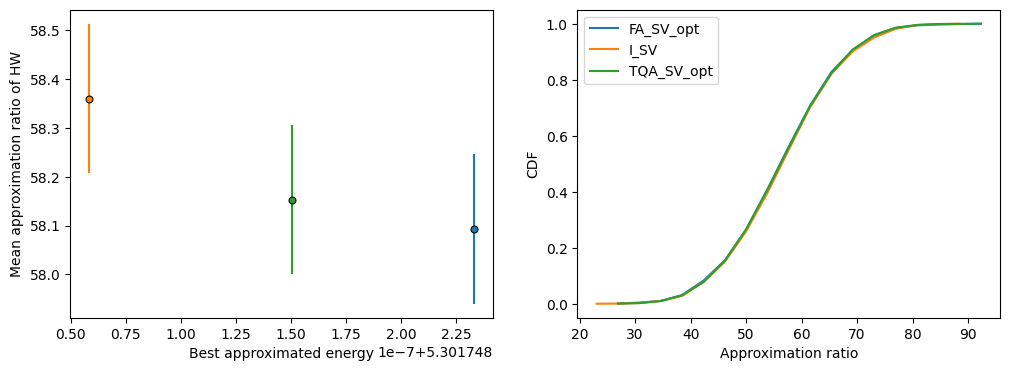

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for idx, mc_cost in enumerate(mc_costs):
    plot_cdf(
        {(k-min_cut)/(max_cut-min_cut)*100: v for k, v in mc_cost.items()}, 
        axis=axs[1], 
        label=res_summary[idx]["metadata"]["circuit_metadata"]["method"]
    )

    _approx_e = [res_summary[idx]["metadata"]["circuit_metadata"]["eval_energy"]]
    axs[0].errorbar(_approx_e, [means[idx]], yerr=[sems[idx]], ms=5, marker="o", mec="k", mew=0.75)

axs[1].legend()
axs[1].set_xlabel("Approximation ratio")
axs[1].set_ylabel("CDF")
axs[0].set_ylabel("Mean approximation ratio of HW")
axs[0].set_xlabel("Best approximated energy")
#fig.savefig(f"{short_name}_hm_results.pdf", bbox_inches="tight")